### Setup Data loader

In [1]:
import pandas as pd
from sklearn.preprocessing import QuantileTransformer
from sklearn.model_selection import train_test_split

from agent.components import RASK

raw_df = pd.read_csv("../statics/metrics_20_0.csv")
converted_df = RASK.preprocess_data(raw_df)


def prepare_chained_data(df: pd.DataFrame, test_size=0.2):

    import torch
    from torch.utils.data import TensorDataset, DataLoader
    import numpy as np

    # 1. Split the interleaved rows
    df_qr = df.iloc[0::3].copy().reset_index(drop=True)
    df_cv = df.iloc[1::3].copy().reset_index(drop=True)
    df_pc = df.iloc[2::3].copy().reset_index(drop=True)

    # 2. Scale each service to 0-100 independently using Pandas
    # This ensures 4 -> 100 for QR and 1500 -> 100 for CV
    # for sub_df in [df_qr, df_cv, df_pc]:
    #     target = sub_df['max_tp']
    #     sub_df['scaled_tp'] = (target - target.min()) / (target.max() - target.min()) * 100

    # This essentially destroys the non-linear relations I think
    qt = QuantileTransformer(output_distribution='uniform', n_quantiles=100)
    # Fit on the original throughput, then transform to 0-100
    df_qr['scaled_tp'] = qt.fit_transform(df_qr[['max_tp']]) * 100
    df_cv['scaled_tp'] = qt.fit_transform(df_cv[['max_tp']]) * 100
    df_pc['scaled_tp'] = qt.fit_transform(df_pc[['max_tp']]) * 100

    # 3. Apply the Bottleneck Condition on the scaled values
    # PC cannot be faster (in % capacity) than CV, which cannot be faster than QR

    qr_final = df_qr['scaled_tp'].values
    cv_final = qr_final + df_cv['scaled_tp'].values
    pc_final = cv_final + df_pc['scaled_tp'].values

    Y_final = np.column_stack([qr_final, cv_final, pc_final])

    # 4. Prepare Features (X)
    # Note: You should still scale X (cores, etc.) so the GP converges well
    X_raw = np.hstack([
        df_qr[['cores', 'data_quality']].values,
        df_cv[['cores', 'data_quality', 'model_size']].values,
        df_pc[['cores', 'data_quality']].values
    ])

    # How often is CV actually capped by QR in your training data?
    # capped_count = (df_cv['scaled_tp'] > df_qr['scaled_tp']).sum()
    # print(f"CV was bottlenecked by QR in {capped_count} out of {len(df_cv)} rows")

    # Simple Min-Max for X
    X_final = (X_raw - X_raw.min(axis=0)) / (X_raw.max(axis=0) - X_raw.min(axis=0))

    # 5. Split and Tensors
    x_train, x_test, y_train, y_test = train_test_split(X_final, Y_final, test_size=test_size)

    t_x_train = torch.tensor(x_train, dtype=torch.float32)
    t_y_train = torch.tensor(y_train, dtype=torch.float32)
    t_x_test = torch.tensor(x_test, dtype=torch.float32)
    t_y_test = torch.tensor(y_test, dtype=torch.float32)

    return DataLoader(TensorDataset(t_x_train, t_y_train), batch_size=64, shuffle=True), t_x_test, t_y_test


train_loader, test_x, test_y = prepare_chained_data(converted_df)


In [2]:
# import gpytorch
#
# test_dataset = TensorDataset(test_x, test_y)
# test_loader = DataLoader(test_dataset, batch_size=1024)
#
# model.eval()
# predictive_means, predictive_variances, test_lls = model.predict(test_loader)
#
# rmse = torch.mean(torch.pow(predictive_means.mean(0) - test_y, 2)).sqrt()
# print(f"RMSE: {rmse.item()}, NLL: {-test_lls.mean().item()}")

### Setup the Structure


In [3]:
import torch
import gpytorch
import numpy as np
from torch.utils.data import TensorDataset, DataLoader


# --- 1. MODEL DEFINITION ---

class ServiceGP(gpytorch.models.ApproximateGP):
    """A standard Variational GP for an individual service."""

    def __init__(self, input_dims, num_inducing=128):
        inducing_points = torch.randn(num_inducing, input_dims)
        variational_distribution = gpytorch.variational.CholeskyVariationalDistribution(num_inducing)
        variational_strategy = gpytorch.variational.VariationalStrategy(
            self, inducing_points, variational_distribution, learn_inducing_locations=True
        )
        super().__init__(variational_strategy)
        self.mean_module = gpytorch.means.ConstantMean()
        # self.mean_module.initialize(constant=torch.tensor([50.0]))

        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel(ard_num_dims=input_dims)
        )
        # self.covar_module.initialize(outputscale=torch.tensor([100.0]))

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)


class ServiceChain(torch.nn.Module):
    """Connects 3 GPs into a chain where outputs of one become inputs to the next."""

    def __init__(self, qr_idx, cv_idx, pc_idx):
        super().__init__()
        self.qr_idx, self.cv_idx, self.pc_idx = qr_idx, cv_idx, pc_idx

        # input_dims = raw_features + 1 (from previous service sample)
        self.qr_gp = ServiceGP(input_dims=len(qr_idx))
        self.cv_gp = ServiceGP(input_dims=len(cv_idx) + 1)
        self.pc_gp = ServiceGP(input_dims=len(pc_idx) + 1)

        self.qr_gp.mean_module.initialize(constant=50.0)
        self.cv_gp.mean_module.initialize(constant=100.0) # QR(50) + CV(50)
        self.pc_gp.mean_module.initialize(constant=150.0) # QR + CV + PC

        self.qr_gp.covar_module.base_kernel.lengthscale = torch.tensor([[0.5] * len(qr_idx)])
        self.cv_gp.covar_module.base_kernel.lengthscale = torch.tensor([[0.5] * (len(cv_idx) + 1)])
        self.pc_gp.covar_module.base_kernel.lengthscale = torch.tensor([[0.5] * (len(pc_idx) + 1)])

        self.qr_likelihood = gpytorch.likelihoods.GaussianLikelihood()
        self.cv_likelihood = gpytorch.likelihoods.GaussianLikelihood()
        self.pc_likelihood = gpytorch.likelihoods.GaussianLikelihood()

    def forward(self, x):
        # Service 1: QR
        qr_dist = self.qr_gp(x[:, self.qr_idx])
        qr_samples = qr_dist.rsample()

        # NORMALIZE: QR targets are 0-100, so divide by 100 to get 0-1
        qr_norm = qr_samples.unsqueeze(-1) / 100.0

        # Service 2: CV
        cv_input = torch.cat([x[:, self.cv_idx], qr_norm], dim=-1)
        cv_dist = self.cv_gp(cv_input)
        cv_samples = cv_dist.rsample()

        # NORMALIZE: CV cumulative targets are 0-200, divide by 200 to get 0-1
        cv_norm = cv_samples.unsqueeze(-1) / 200.0

        # Service 3: PC
        pc_input = torch.cat([x[:, self.pc_idx], cv_norm], dim=-1)
        pc_dist = self.pc_gp(pc_input)

        return qr_dist, cv_dist, pc_dist

### Do the training of the GP

In [4]:
model = ServiceChain(qr_idx=[0, 1], cv_idx=[2, 3, 4], pc_idx=[5, 6])
if torch.cuda.is_available():
    model, test_x, test_y = model.cuda(), test_x.cuda(), test_y.cuda()

# Training setup
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
mll_qr = gpytorch.mlls.VariationalELBO(model.qr_likelihood, model.qr_gp, num_data=len(train_loader.dataset))
mll_cv = gpytorch.mlls.VariationalELBO(model.cv_likelihood, model.cv_gp, num_data=len(train_loader.dataset))
mll_pc = gpytorch.mlls.VariationalELBO(model.pc_likelihood, model.pc_gp, num_data=len(train_loader.dataset))

model.train()
for epoch in range(500):
    with gpytorch.settings.cholesky_jitter(1e-3):
        for x_batch, y_batch in train_loader:
            if torch.cuda.is_available(): x_batch, y_batch = x_batch.cuda(), y_batch.cuda()

            optimizer.zero_grad()
            qr_d, cv_d, pc_d = model(x_batch)

            # Loss is sum of ELBOs for all components
            loss = -mll_qr(qr_d, y_batch[:, 0]) - mll_cv(cv_d, y_batch[:, 1]) - mll_pc(pc_d, y_batch[:, 2])

            loss.backward()
            optimizer.step()
    if epoch % 10 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.4f}")


Epoch 0 | Loss: 3386.7017
Epoch 10 | Loss: 3947.9395
Epoch 20 | Loss: 3384.3594
Epoch 30 | Loss: 2690.4688
Epoch 40 | Loss: 2944.8035
Epoch 50 | Loss: 2058.2605
Epoch 60 | Loss: 1561.1732
Epoch 70 | Loss: 1636.8552
Epoch 80 | Loss: 1286.1490
Epoch 90 | Loss: 1285.4294
Epoch 100 | Loss: 1187.9668
Epoch 110 | Loss: 1089.8582
Epoch 120 | Loss: 950.6534
Epoch 130 | Loss: 1022.8643
Epoch 140 | Loss: 627.8245
Epoch 150 | Loss: 847.1621
Epoch 160 | Loss: 1003.7747
Epoch 170 | Loss: 433.4667
Epoch 180 | Loss: 473.4047
Epoch 190 | Loss: 620.8112
Epoch 200 | Loss: 579.9155
Epoch 210 | Loss: 381.2834
Epoch 220 | Loss: 398.5599
Epoch 230 | Loss: 401.2937
Epoch 240 | Loss: 392.8661
Epoch 250 | Loss: 270.0211
Epoch 260 | Loss: 337.3491
Epoch 270 | Loss: 375.2148
Epoch 280 | Loss: 396.1652
Epoch 290 | Loss: 242.1198
Epoch 300 | Loss: 237.4034
Epoch 310 | Loss: 246.3220
Epoch 320 | Loss: 281.2164
Epoch 330 | Loss: 249.0513
Epoch 340 | Loss: 189.4823
Epoch 350 | Loss: 197.9128
Epoch 360 | Loss: 265.157

### Do some sort of inference

In [5]:
model.eval()
all_samples = []
num_mc = 100 # that many simulations for each of the data points

with torch.no_grad(), gpytorch.settings.cholesky_jitter(1e-3):
    for _ in range(num_mc):
        # By calling the model 1000 times, the internal .rsample()
        # maintains the correlation for each individual pass.
        qr_d, cv_d, pc_d = model(test_x)

        # Take ONE sample from each distribution
        # These are correlated because they shared the same latent pass
        s = torch.stack([qr_d.sample(), cv_d.sample(), pc_d.sample()], dim=-1)
        all_samples.append(s)

    # Stack into (1000, 60, 3)
    combined_samples = torch.stack(all_samples, dim=0).cpu().numpy()

    # EXAMPLE SLO: Chain-wide latency (Sum) < 1500ms
    # unscaled_samples[:, :, 0] is QR, [:, :, 1] is CV, etc.
    cumulative_latency = combined_samples[:, :, 2]
    # total_metric = combined_samples.min(axis=-1)

    threshold = 20
    slo_fulfilled = (cumulative_latency < threshold).mean(axis=0)  # Mean across samples = Probability

print("\n--- SLO Analysis ---")
print(f"Average probability of chain fulfillment: {slo_fulfilled.mean():.2%}")
print(f"Probabilities for first 5 test cases: {slo_fulfilled[:5]}")




--- SLO Analysis ---
Average probability of chain fulfillment: 0.00%
Probabilities for first 5 test cases: [0. 0. 0. 0. 0.]


CV Service Feature Importance (Cores, Quality, Model Size, QR_Input):
tensor([[0.8045, 0.6067, 0.5129, 0.3927]], grad_fn=<SoftplusBackward0>)
PC Service Feature Importance (Cores, Quality, QR_Input):
tensor([[2.0055, 0.5151, 0.1686]], grad_fn=<SoftplusBackward0>)


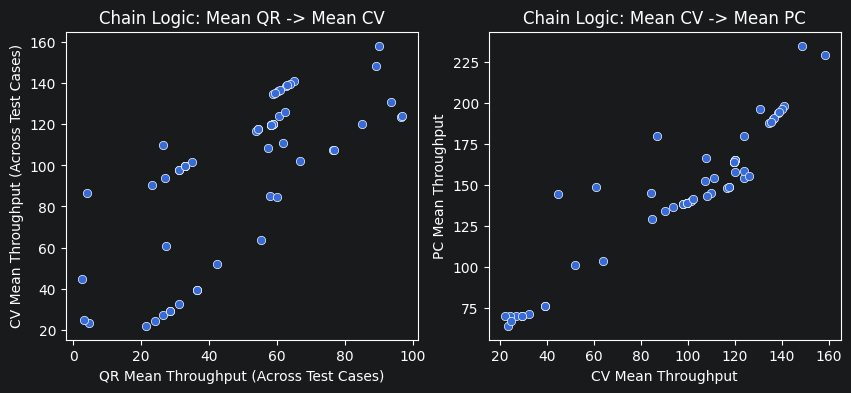

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Average across the 1000 simulations to get one value per test case
test_case_means = combined_samples.mean(axis=0) # Result shape: (60, 3)

# 2. Plotting the relationship across ALL test cases
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
# X-axis: QR Mean for each test case, Y-axis: CV Mean for each test case
sns.scatterplot(x=test_case_means[:, 0], y=test_case_means[:, 1])
plt.xlabel('QR Mean Throughput (Across Test Cases)')
plt.ylabel('CV Mean Throughput (Across Test Cases)')
plt.title('Chain Logic: Mean QR -> Mean CV')

plt.subplot(1, 2, 2)
sns.scatterplot(x=test_case_means[:, 1], y=test_case_means[:, 2])
plt.xlabel('CV Mean Throughput')
plt.ylabel('PC Mean Throughput')
plt.title('Chain Logic: Mean CV -> Mean PC')


# Print lengthscales for CV service
# Lower value = Higher importance/impact
print("CV Service Feature Importance (Cores, Quality, Model Size, QR_Input):")
print(model.cv_gp.covar_module.base_kernel.lengthscale)

print("PC Service Feature Importance (Cores, Quality, QR_Input):")
print(model.pc_gp.covar_module.base_kernel.lengthscale)

--- Expected Outcomes for Test Case 0 ---
QR Latency (Base):         62.55
CV Latency (QR + CV):     138.58  (Local CV: 76.03)
PC Latency (Total Chain):  194.05  (Local PC: 55.47)


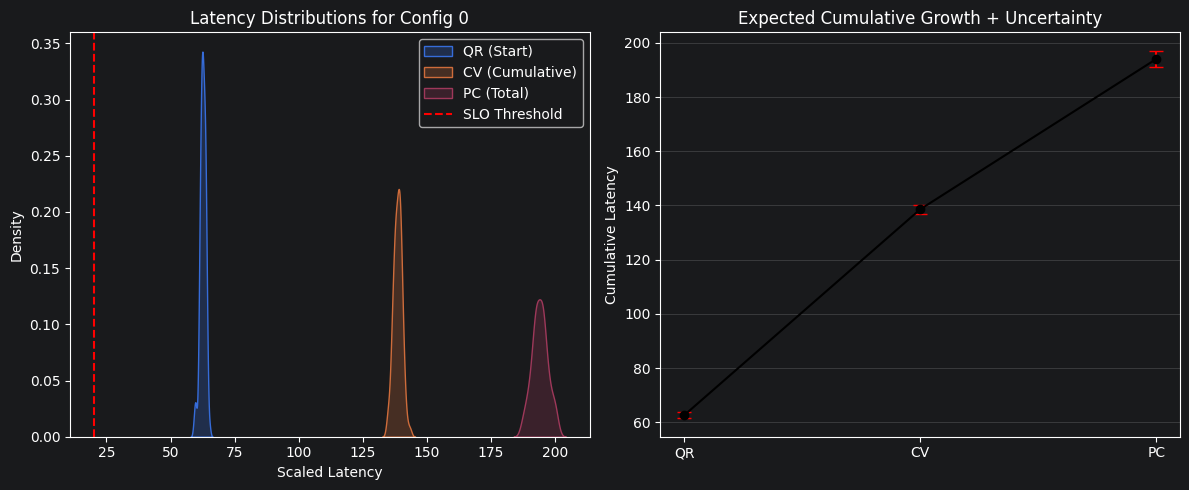

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pick one specific hardware configuration (test case)
test_idx = 0
# Shape: (1000 simulations, 3 services)
single_chain_sims = combined_samples[:, test_idx, :]

# 1. Calculate Expected Outcomes (Means)
expected_qr = single_chain_sims[:, 0].mean()
expected_cv = single_chain_sims[:, 1].mean()
expected_pc = single_chain_sims[:, 2].mean()

print(f"--- Expected Outcomes for Test Case {test_idx} ---")
print(f"QR Latency (Base):         {expected_qr:.2f}")
print(f"CV Latency (QR + CV):     {expected_cv:.2f}  (Local CV: {expected_cv - expected_qr:.2f})")
print(f"PC Latency (Total Chain):  {expected_pc:.2f}  (Local PC: {expected_pc - expected_cv:.2f})")

# 2. Plotting the "Growth" of Latency
plt.figure(figsize=(12, 5))

# Plot A: The Probability Density for each stage
plt.subplot(1, 2, 1)
sns.kdeplot(single_chain_sims[:, 0], label='QR (Start)', fill=True)
sns.kdeplot(single_chain_sims[:, 1], label='CV (Cumulative)', fill=True)
sns.kdeplot(single_chain_sims[:, 2], label='PC (Total)', fill=True)
plt.axvline(threshold, color='red', linestyle='--', label='SLO Threshold')
plt.title(f"Latency Distributions for Config {test_idx}")
plt.xlabel("Scaled Latency")
plt.legend()

# Plot B: The "Staircase" of Uncertainty
plt.subplot(1, 2, 2)
stages = ['QR', 'CV', 'PC']
means = [expected_qr, expected_cv, expected_pc]
# Standard deviation as the "error bar"
stds = [single_chain_sims[:, i].std() for i in range(3)]

plt.errorbar(stages, means, yerr=stds, fmt='-o', capsize=5, color='black', ecolor='red')
plt.title("Expected Cumulative Growth + Uncertainty")
plt.ylabel("Cumulative Latency")
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


# Repeat your 'cores' feature 10 times to match the 600 points
# cores_repeated = np.repeat(test_x[:, 0].cpu().numpy(), 10)
#
# plt.scatter(flattened_samples[:, 0], flattened_samples[:, 1],
#             c=cores_repeated, cmap='viridis', alpha=0.5)
# plt.colorbar(label='Normalized Cores')


In [ ]:

# --- MODEL VALIDATION ---
# Get the mean prediction for each service (mean across Monte Carlo samples)
# unscaled_samples shape is (1000, N_test, 3)
predicted_means = combined_samples.mean(axis=0)

# Unscale the ground truth test_y to compare in real units
actual_y = test_y.cpu().numpy()

# Calculate Error for each service
for i, name in enumerate(['QR', 'CV', 'PC']):
    rmse = np.sqrt(np.mean((predicted_means[:, i] - actual_y[:, i]) ** 2))
    print(f"{name} Service RMSE: {rmse:.4f}")